# 1 — Entraînement & évaluation du modèle ASL

Exécute les cellules **dans l'ordre, de haut en bas**. Ce notebook :
1. charge et **normalise** les landmarks,
2. **compare** plusieurs classifieurs (pour justifier le choix),
3. entraîne le **modèle final** (MLP + augmentation),
4. produit une **évaluation complète** (matrice de confusion, F1, courbes).

En sortie : `asl_mediapipe_mlp_model.h5` et `labels.json`.


In [1]:
import numpy as np
import pandas as pd
import json, time
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
import matplotlib.pyplot as plt   # si erreur : pip install matplotlib


2026-07-02 11:51:44.971855: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-02 11:51:44.972904: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-02 11:51:44.988713: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-02 11:51:44.988727: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-02 11:51:44.989245: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

## 1. Chargement + normalisation des landmarks


In [2]:
df = pd.read_csv("asl_mediapipe_keypoints_dataset.csv")
X_raw = df.iloc[:, :-1].values.astype(np.float32)
y = df["label"].values

def normalize_landmarks(landmarks):
    # recentrage sur le poignet + mise a l'echelle par la taille de la main
    lm = landmarks.astype(np.float32).copy()
    lm -= lm[0]
    scale = np.linalg.norm(lm[9, :2])
    if scale < 1e-6:
        scale = 1e-6
    lm /= scale
    return lm.flatten()

X_norm = np.array([normalize_landmarks(r.reshape(21, 3)) for r in X_raw], dtype=np.float32)
print("Donnees normalisees :", X_norm.shape, "|", len(np.unique(y)), "classes")


Donnees normalisees : (59801, 63) | 28 classes


## 2. Comparaison de modèles (baseline)

On compare trois classifieurs sur les **mêmes** données normalisées (sans augmentation) pour justifier objectivement le choix du MLP. Très utile à présenter dans le rapport.


In [3]:
enc = LabelEncoder()
y_enc = enc.fit_transform(y)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_norm, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

results = {}

rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(Xc_tr, yc_tr)
results["Random Forest"] = accuracy_score(yc_te, rf.predict(Xc_te))

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xc_tr, yc_tr)
results["k-NN (k=5)"] = accuracy_score(yc_te, knn.predict(Xc_te))

quick = Sequential([
    Dense(256, activation="relu", input_shape=(Xc_tr.shape[1],)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dense(len(enc.classes_), activation="softmax"),
])
quick.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
quick.fit(Xc_tr, to_categorical(yc_tr, len(enc.classes_)),
          epochs=12, batch_size=128, verbose=0)
qpred = np.argmax(quick.predict(Xc_te, verbose=0), axis=1)
results["MLP (rapide)"] = accuracy_score(yc_te, qpred)

print("=== Comparaison (precision test) ===")
for name, acc in sorted(results.items(), key=lambda kv: -kv[1]):
    print(f"  {name:16s} : {acc*100:5.2f}%")


=== Comparaison (precision test) ===
  Random Forest    : 99.38%
  k-NN (k=5)       : 99.24%
  MLP (rapide)     : 99.23%


## 3. Modèle final : MLP + augmentation

Augmentation (rotation, échelle, bruit) + **symétrie gauche/droite**, puis entraînement du MLP avec BatchNorm, Dropout, *label smoothing* et arrêt automatique.


In [4]:
def augment(features):
    lm = features.reshape(21, 3).copy()
    theta = np.deg2rad(np.random.uniform(-15, 15))
    c, s = np.cos(theta), np.sin(theta)
    lm[:, :2] = lm[:, :2] @ np.array([[c, -s], [s, c]], dtype=np.float32).T
    lm *= np.random.uniform(0.9, 1.1)
    lm += np.random.normal(0, 0.02, lm.shape).astype(np.float32)
    return lm.flatten()

def mirror(features):
    lm = features.reshape(21, 3).copy()
    lm[:, 0] = -lm[:, 0]
    return lm.flatten()

N_AUG = 2  # baisse a 1 si l'entrainement est trop lent / la RAM sature

Xa, ya = [], []
for feat, label in zip(X_norm, y):
    variants = [feat, mirror(feat)]
    for _ in range(N_AUG):
        variants.append(augment(feat))
        variants.append(augment(mirror(feat)))
    Xa.extend(variants); ya.extend([label] * len(variants))
Xa = np.array(Xa, dtype=np.float32); ya = np.array(ya)
print("Jeu augmente :", Xa.shape)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(ya)
Y = to_categorical(y_encoded, num_classes=len(encoder.classes_))
X_train, X_test, y_train, y_test = train_test_split(
    Xa, Y, test_size=0.2, random_state=42, stratify=y_encoded)

model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation="relu"),
    BatchNormalization(), Dropout(0.3),
    Dense(64, activation="relu"), Dropout(0.2),
    Dense(len(encoder.classes_), activation="softmax"),
])
model.compile(optimizer="adam",
              loss=CategoricalCrossentropy(label_smoothing=0.1),
              metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]
history = model.fit(X_train, y_train, epochs=40, batch_size=128,
                    validation_split=0.2, callbacks=callbacks, verbose=1)

model.save("asl_mediapipe_mlp_model.h5")
with open("labels.json", "w") as f:
    json.dump(list(encoder.classes_), f, ensure_ascii=False)
print("OK -> asl_mediapipe_mlp_model.h5 + labels.json")


Jeu augmente : (358806, 63)
Epoch 1/40
1795/1795 [==============================] - 4s 2ms/step - loss: 1.0167 - accuracy: 0.9040 - val_loss: 0.7400 - val_accuracy: 0.9774 - lr: 0.0010
Epoch 2/40
1795/1795 [==============================] - 3s 2ms/step - loss: 0.8161 - accuracy: 0.9666 - val_loss: 0.7236 - val_accuracy: 0.9783 - lr: 0.0010
Epoch 3/40
1795/1795 [==============================] - 3s 2ms/step - loss: 0.7886 - accuracy: 0.9722 - val_loss: 0.7046 - val_accuracy: 0.9836 - lr: 0.0010
Epoch 4/40
1795/1795 [==============================] - 3s 2ms/step - loss: 0.7738 - accuracy: 0.9753 - val_loss: 0.7004 - val_accuracy: 0.9828 - lr: 0.0010
Epoch 5/40
1795/1795 [==============================] - 3s 2ms/step - loss: 0.7655 - accuracy: 0.9772 - val_loss: 0.7013 - val_accuracy: 0.9827 - lr: 0.0010
Epoch 6/40
1795/1795 [==============================] - 3s 2ms/step - loss: 0.7581 - accuracy: 0.9786 - val_loss: 0.6965 - val_accuracy: 0.9852 - lr: 0.0010
Epoch 7/40
1795/1795 [========

/home/lamsn01/Sign-Language-Recognition-System/Sign_to_Sentence Project/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## 4. Évaluation finale

Précision, rapport par classe, **courbes d'entraînement**, **matrice de confusion** et **F1 par classe**. Ces graphiques sont parfaits à insérer dans ton rapport.


Precision test finale : 99.23 %
              precision    recall  f1-score   support

           A       1.00      1.00      1.00      2503
           B       1.00      1.00      1.00      2582
           C       0.99      1.00      0.99      2155
           D       1.00      0.99      0.99      2760
           E       0.99      0.99      0.99      2642
           F       1.00      1.00      1.00      3321
           G       1.00      1.00      1.00      2749
           H       1.00      1.00      1.00      2757
           I       0.99      0.98      0.98      2726
           J       0.98      0.98      0.98      2922
           K       1.00      1.00      1.00      3118
           L       1.00      1.00      1.00      2903
           M       0.95      0.98      0.97      1420
           N       0.98      0.94      0.96      1195
           O       0.99      1.00      0.99      2593
           P       1.00      0.99      0.99      2308
           Q       0.99      0.99      0.99      

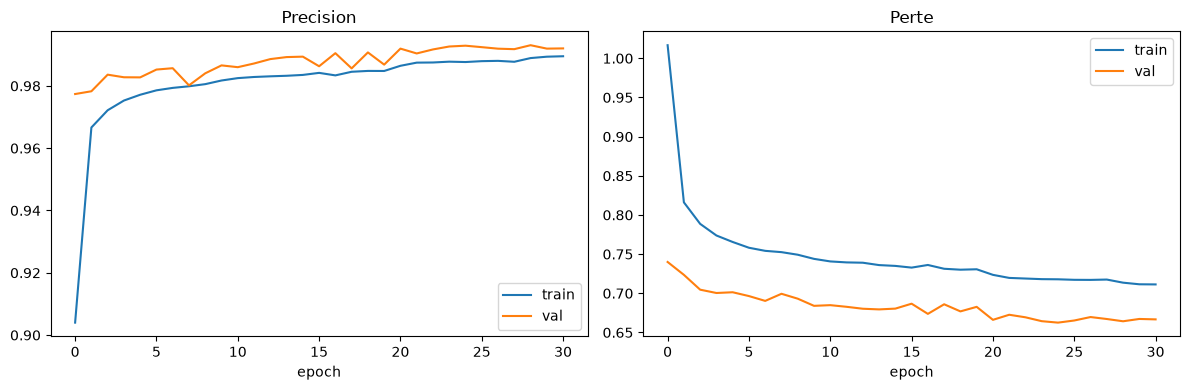

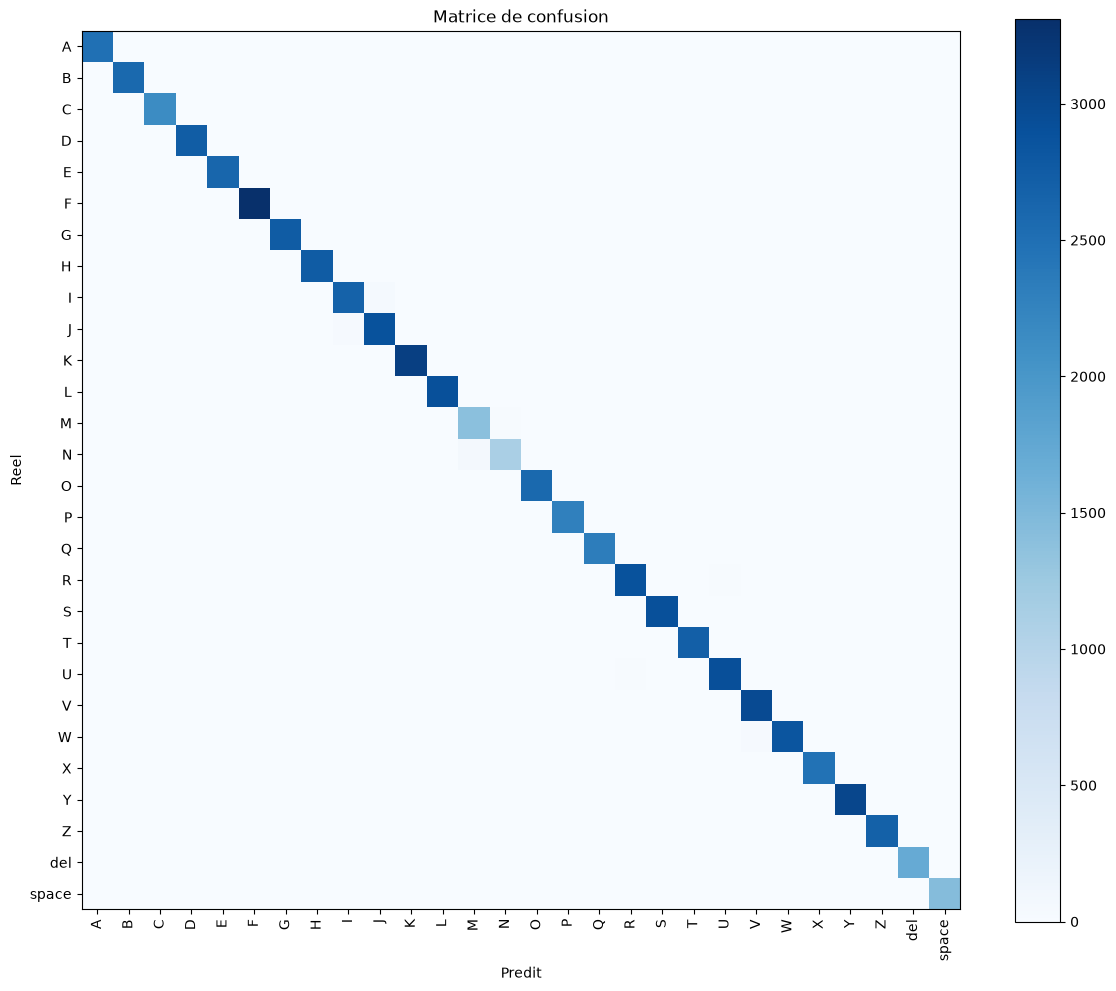

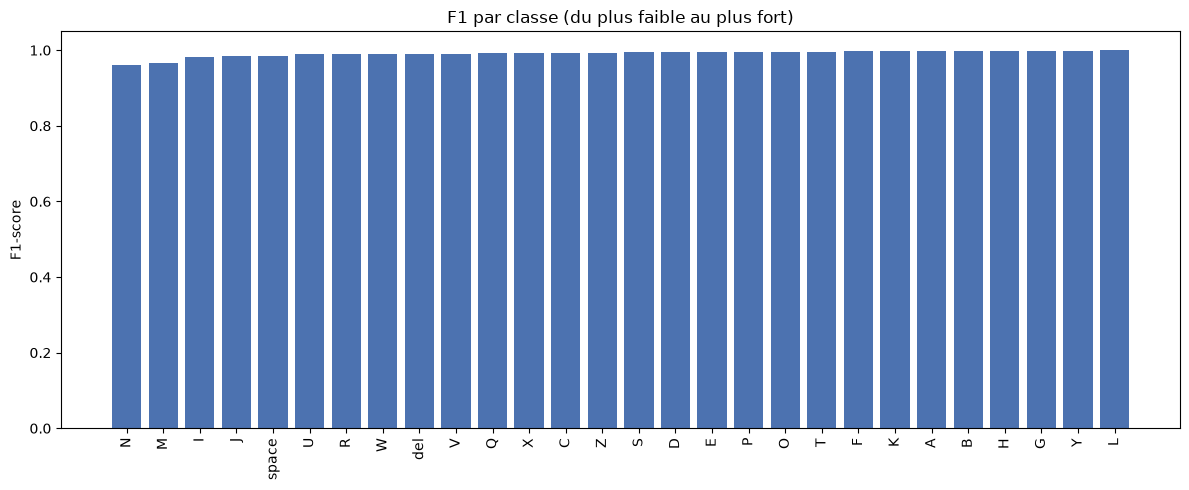

In [5]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("Precision test finale :", round(acc*100, 2), "%")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
labels_list = list(encoder.classes_)
print(classification_report(y_true, y_pred, target_names=labels_list))

# --- Courbes d'entrainement ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Precision"); plt.xlabel("epoch"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Perte"); plt.xlabel("epoch"); plt.legend()
plt.tight_layout(); plt.show()

# --- Matrice de confusion ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues"); plt.colorbar()
plt.xticks(range(len(labels_list)), labels_list, rotation=90)
plt.yticks(range(len(labels_list)), labels_list)
plt.xlabel("Predit"); plt.ylabel("Reel"); plt.title("Matrice de confusion")
plt.tight_layout(); plt.show()

# --- F1 par classe ---
f1s = f1_score(y_true, y_pred, average=None)
order = np.argsort(f1s)
plt.figure(figsize=(12, 5))
plt.bar([labels_list[i] for i in order], [f1s[i] for i in order], color="#4C72B0")
plt.ylabel("F1-score"); plt.title("F1 par classe (du plus faible au plus fort)")
plt.xticks(rotation=90); plt.tight_layout(); plt.show()
